# Caustic Optimization Demo

End-to-end Python demo: construct a wave tank, set up actuators, analytically warm-start, then optimize with Adam to reproduce a target caustic pattern.

This notebook runs in the `wavetank` uv environment.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from wavetank import (
    Tank, Actuator, build_propagator,
    steady_state_amplitudes, caustic_image,
    pack_complex, unpack_complex,
    cosine_loss, load_target_image,
    Stage, optimize_caustic,
    analyze_target, analytical_solve, setup_from_target,
)

print(f"JAX {jax.__version__} on {jax.default_backend()}")


JAX 0.9.2 on cpu


## 1. Define tank and target

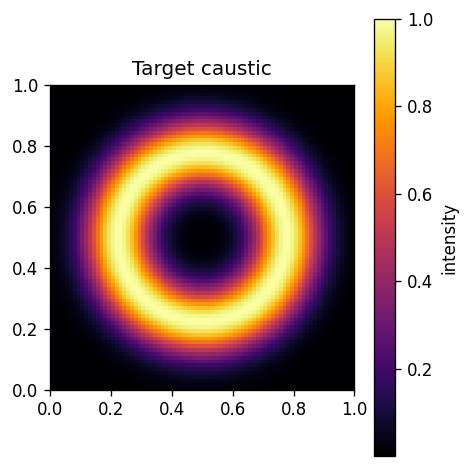

Target shape: (80, 80)


In [2]:
# Physical parameters
tank = Tank(Lx=1.0, Ly=1.0, depth=0.12, damping=0.02)

# Target: bright ring pattern
nx, ny = 80, 80
xs = np.linspace(0, tank.Lx, nx)
ys = np.linspace(0, tank.Ly, ny)
XX, YY = np.meshgrid(xs, ys, indexing='ij')
cx, cy = 0.5, 0.5
r = np.sqrt((XX - cx)**2 + (YY - cy)**2)
sigma_r = 0.08
target = np.exp(-((r - 0.28)**2) / (2 * sigma_r**2)).astype(np.float32)
target /= target.max()

plt.figure(figsize=(4, 4))
plt.imshow(target.T, origin='lower', extent=[0, tank.Lx, 0, tank.Ly], cmap='inferno')
plt.colorbar(label='intensity')
plt.title('Target caustic')
plt.tight_layout()
plt.savefig('target.png', dpi=120)
plt.show()
print(f"Target shape: {target.shape}")


## 2. Auto-configure: analyze target → build propagator → analytical warm-start

In [3]:
setup = setup_from_target(
    target, tank,
    nx=nx, ny=ny,
    energy_fraction=0.90,
    n_modes_max=30,
    T_eval=1.0,
)

prop       = setup['prop']
Omega_freqs = setup['Omega_freqs']
target_bl  = setup['target_bl']  # band-limited version of target
freqs      = setup['freqs']
p0         = setup['p0']

print(f"Propagator: {len(prop.omega)} modes, {prop.n_act} actuators, {len(Omega_freqs)} frequencies")
print(f"Frequencies: {freqs.round(2)} Hz")
print(f"p0 norm: {np.linalg.norm(p0):.4g}")


  Target Analysis
  Grid: 80×80
  Modes capturing 90% energy: 7
  Highest mode indices: m_max=4, n_max=4
  Frequency range: 1.00 – 1.81 Hz
  Suggested: n_modes=5, n_freq=4, n_act=20 (5/side)
  Top 5 modes by energy:
    (2,4)  f=1.81 Hz  energy=25.1%
    (4,2)  f=1.81 Hz  energy=25.1%
    (2,0)  f=1.00 Hz  energy=11.1%
    (0,2)  f=1.00 Hz  energy=11.1%
    (4,0)  f=1.68 Hz  energy=8.4%

Setup: 20 actuators, 4 frequencies (1.00–1.81 Hz), 24 modes
Grid: 80×80,  Parameters: 160
  Analytical solve: 24/24 modes achievable
  Caustic contrast 2.624 → 0.5 (scale=0.191)
  ‖a_desired‖ = 0.0593,  ‖p0‖ = 0.03713
Propagator: 24 modes, 20 actuators, 4 frequencies
Frequencies: [1.   1.27 1.54 1.81] Hz
p0 norm: 0.03713


## 3. Evaluate analytical warm-start caustic

Analytical warm-start cosine similarity: 0.6459


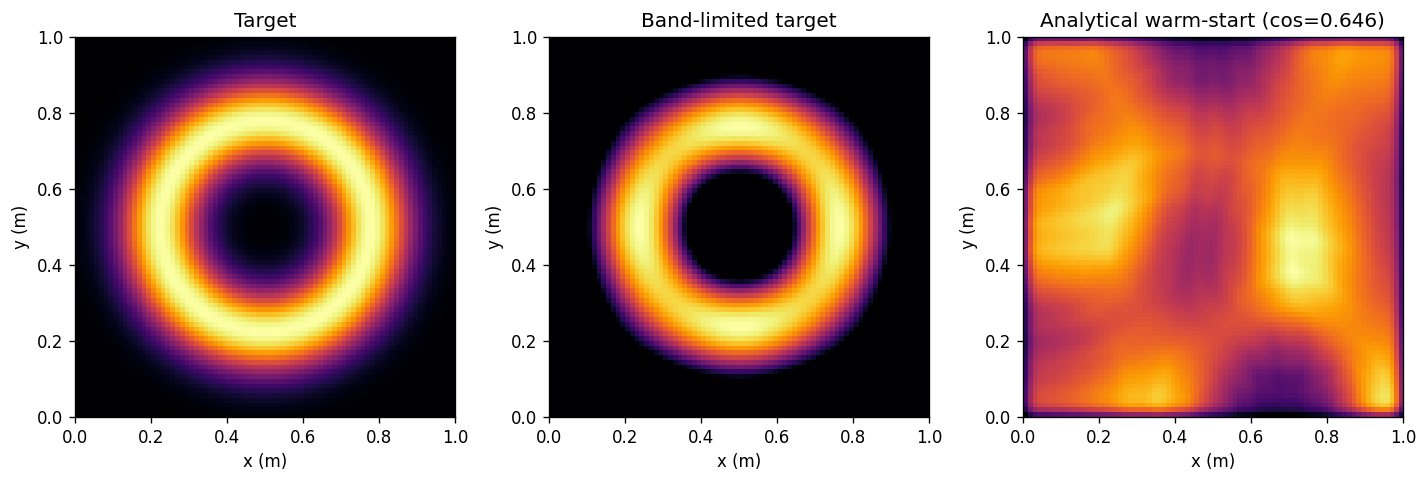

In [4]:
n_act = prop.n_act
n_freq = len(Omega_freqs)
X0, Y0 = unpack_complex(jnp.asarray(p0), n_act, n_freq)
P0 = X0 + 1j * Y0
a0 = steady_state_amplitudes(prop, P0, jnp.asarray(Omega_freqs), T=1.0)
_, _, I0 = caustic_image(prop, a0, sigma=0.02)
I0_np = np.asarray(I0)

cos_sim = float(1 - cosine_loss(I0, jnp.asarray(target_bl)))
print(f"Analytical warm-start cosine similarity: {cos_sim:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[0].set_title('Target')
axes[1].imshow(target_bl.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[1].set_title('Band-limited target')
axes[2].imshow(I0_np.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[2].set_title(f'Analytical warm-start (cos={cos_sim:.3f})')
for ax in axes:
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
plt.tight_layout()
plt.savefig('warmstart.png', dpi=120)
plt.show()


## 4. Optimize

σ=0.040:   0%|          | 0/300 [00:00<?, ?it/s]

σ=0.040:   0%|          | 0/300 [00:00<?, ?it/s, loss=0.2877]

σ=0.040:   0%|          | 1/300 [00:00<01:05,  4.57it/s, loss=0.2877]

σ=0.040:   0%|          | 1/300 [00:00<01:05,  4.57it/s, loss=0.2695]

σ=0.040:   0%|          | 1/300 [00:00<01:05,  4.57it/s, loss=0.2525]

...

σ=0.010:  67%|██████▋   | 200/300 [00:00<00:00, 934.35it/s, loss=0.0876]

σ=0.010:  67%|██████▋   | 200/300 [00:00<00:00, 934.35it/s, loss=0.0875]

σ=0.010:  67%|██████▋   | 200/300 [00:00<00:00, 934.35it/s, loss=0.0876]

σ=0.010:  67%|██████▋   | 200/300 [00:00<00:00, 934.35it/s, loss=0.0876]

σ=0.010: 100%|██████████| 300/300 [00:00<00:00, 962.71it/s, loss=0.0876]

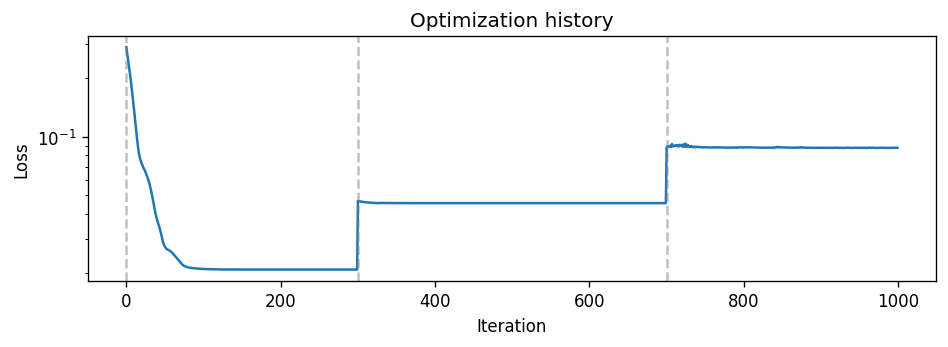

In [5]:
stages = (
    Stage(sigma=0.04, sigma_blur=0.04, iters=300),
    Stage(sigma=0.02, sigma_blur=0.02, iters=400),
    Stage(sigma=0.01, sigma_blur=0.01, iters=300),
)

params_opt, loss_history = optimize_caustic(
    prop, target_bl, Omega_freqs, T_eval=1.0,
    stages=stages,
    lr=5e-4,
    lambda_energy=1e-6,
    loss_type='cosine',
    p0=p0,
)

plt.figure(figsize=(8, 3))
plt.semilogy(loss_history)
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.title('Optimization history')
for i, s in enumerate(stages):
    plt.axvline(x=sum(st.iters for st in stages[:i]), color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('loss_history.png', dpi=120)
plt.show()


## 5. Evaluate optimized result

Optimized cosine similarity: 0.8493  (warm-start: 0.6459)


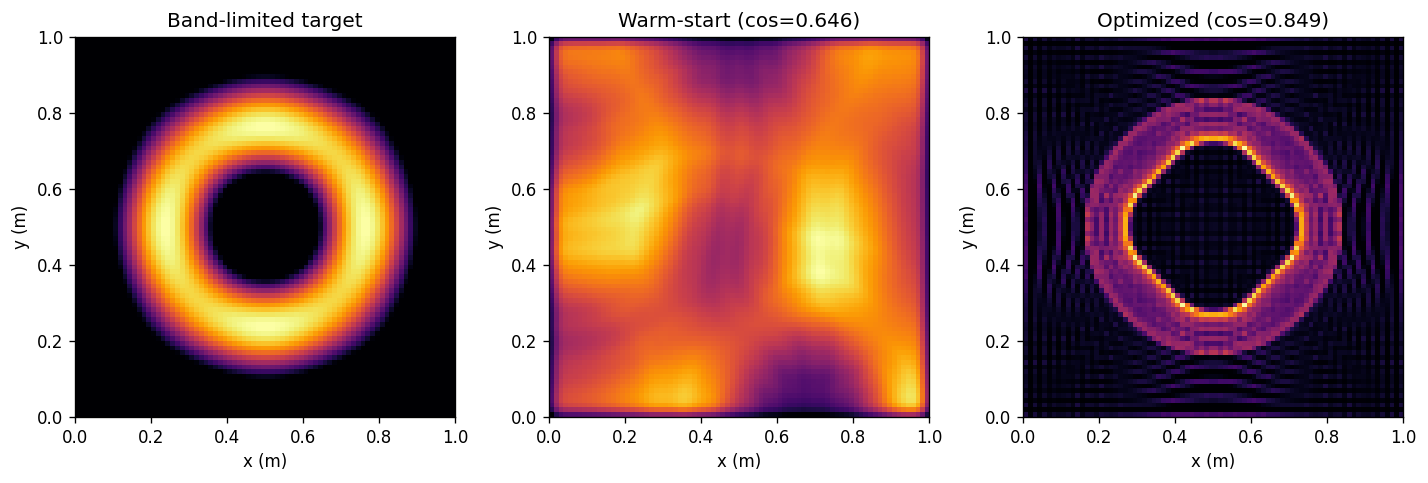

In [6]:
X_opt, Y_opt = unpack_complex(jnp.asarray(params_opt), n_act, n_freq)
P_opt = X_opt + 1j * Y_opt
a_opt = steady_state_amplitudes(prop, P_opt, jnp.asarray(Omega_freqs), T=1.0)
_, _, I_opt = caustic_image(prop, a_opt, sigma=0.005)
I_opt_np = np.asarray(I_opt)

cos_sim_opt = float(1 - cosine_loss(I_opt, jnp.asarray(target_bl)))
print(f"Optimized cosine similarity: {cos_sim_opt:.4f}  (warm-start: {cos_sim:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_bl.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[0].set_title('Band-limited target')
axes[1].imshow(I0_np.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[1].set_title(f'Warm-start (cos={cos_sim:.3f})')
axes[2].imshow(I_opt_np.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[2].set_title(f'Optimized (cos={cos_sim_opt:.3f})')
for ax in axes:
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
plt.tight_layout()
plt.savefig('optimized.png', dpi=120)
plt.show()


## 6. Surface and actuator visualization

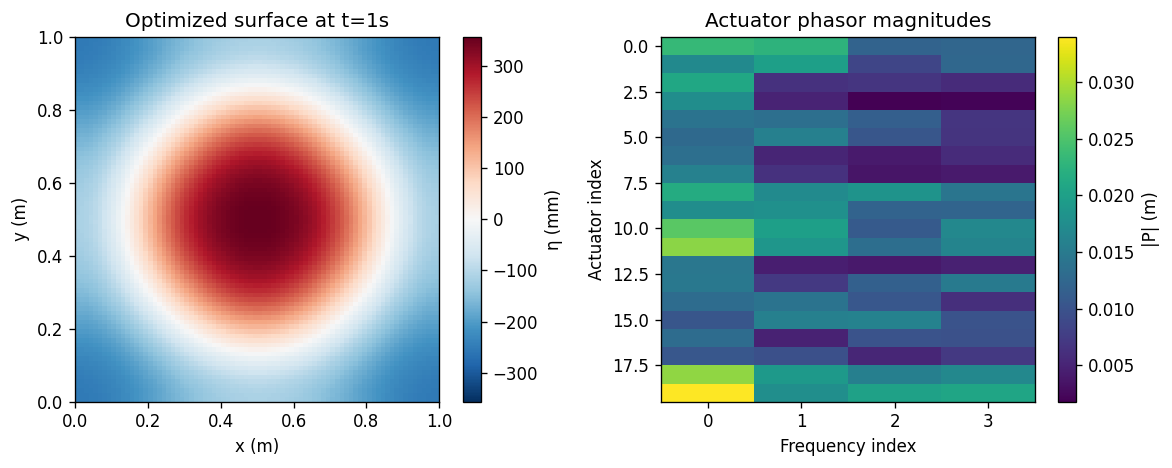

Max surface displacement: 356.60 mm
Actuator RMS amplitude: 14.582 mm


In [7]:
from wavetank import reconstruct_surface

eta_opt, _, _ = reconstruct_surface(prop, a_opt)
eta_np = np.asarray(eta_opt) * 1000  # mm

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(eta_np.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly],
                    cmap='RdBu_r', vmin=-np.abs(eta_np).max(), vmax=np.abs(eta_np).max())
plt.colorbar(im, ax=axes[0], label='η (mm)')
axes[0].set_title('Optimized surface at t=1s')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')

# Actuator amplitudes at each frequency
n_act = prop.n_act
amps = jnp.sqrt(X_opt**2 + Y_opt**2)  # [n_act, n_freq]
im2 = axes[1].imshow(np.asarray(amps), aspect='auto', cmap='viridis')
plt.colorbar(im2, ax=axes[1], label='|P| (m)')
axes[1].set_title('Actuator phasor magnitudes')
axes[1].set_xlabel('Frequency index'); axes[1].set_ylabel('Actuator index')
plt.tight_layout()
plt.savefig('surface_actuators.png', dpi=120)
plt.show()

print(f"Max surface displacement: {float(jnp.abs(eta_opt).max())*1000:.2f} mm")
print(f"Actuator RMS amplitude: {float(jnp.sqrt(jnp.mean(amps**2)))*1000:.3f} mm")
